# Crypto Sentiment vs. Trader Performance Analysis
Exploratory data analysis investigating how Hyperliquid trader behavior and profitability shift across Bitcoin Fear & Greed Index phases.

**Datasets:**
- `data/historical_data.csv` — Hyperliquid trade-level execution log (211,224 trades, 32 accounts, 246 coins)
- `data/fear_greed_index.csv` — Daily Bitcoin Fear & Greed Index (2018–2025)


## Step 1: Data Ingestion & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

trades = pd.read_csv('data/historical_data.csv')
sentiment = pd.read_csv('data/fear_greed_index.csv')

print("Trades:", trades.shape)
print("Sentiment:", sentiment.shape)
trades.head()


Trades: (211224, 16)
Sentiment: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [2]:
# Basic schema check
print(trades.dtypes)
print()
print(trades.isna().sum())


Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [3]:
# Standardize timestamps to plain dates so trade logs align with the daily sentiment index.
# 'Timestamp IST' is in DD-MM-YYYY HH:MM format.
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['datetime'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

print("Trade date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())


Trade date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02


In [4]:
# Data quality: drop invalid anomalies.
# - Size USD <= 0 has no real economic footprint (dust / failed fills)
# - Duplicate rows (rare, but check)
before = len(trades)

trades = trades[trades['Size USD'] > 0].copy()
trades = trades.drop_duplicates()

print(f"Removed {before - len(trades)} invalid/duplicate rows ({before} -> {len(trades)})")

# Note: the dataset has NO explicit 'leverage' column. We build a leverage PROXY
# in Step 3 from position size (Size USD), clearly labeled as a proxy rather than
# true account leverage (which would require margin/equity data not present here).


Removed 43 invalid/duplicate rows (211224 -> 211181)


## Step 2: Merging Datasets
Join every individual trade to the Fear & Greed classification active on that trade's date.

In [5]:
merged = trades.merge(
    sentiment[['date', 'value', 'classification']],
    on='date',
    how='inner'
)

print(f"Trades before merge: {len(trades):,}")
print(f"Trades after merge:  {len(merged):,}  (rows dropped had no matching sentiment date)")
merged[['date', 'Account', 'Coin', 'Side', 'Size USD', 'Closed PnL', 'value', 'classification']].head()


Trades before merge: 211,181
Trades after merge:  211,175  (rows dropped had no matching sentiment date)


,date,Account,Coin,Side,Size USD,Closed PnL,value,classification
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,7872.16,0.0,80,Extreme Greed
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,127.68,0.0,80,Extreme Greed
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1150.63,0.0,80,Extreme Greed
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,1142.04,0.0,80,Extreme Greed
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,69.75,0.0,80,Extreme Greed


In [6]:
merged['classification'].value_counts()


classification
Fear             61826
Greed            50283
Extreme Greed    39980
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

## Step 3: Feature Engineering

In [7]:
# --- Win Rate per account, per sentiment bucket ---
# A trade is a "win" if it realized a positive Closed PnL (closing trades only carry non-zero PnL;
# opens/adds carry 0 and are excluded from win-rate math to avoid diluting it).
closed = merged[merged['Closed PnL'] != 0].copy()
closed['is_win'] = closed['Closed PnL'] > 0

win_rate = (
    closed.groupby(['Account', 'classification'])['is_win']
    .mean()
    .reset_index()
    .rename(columns={'is_win': 'win_rate'})
)
win_rate.head(10)


,Account,classification,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,1.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,0.256098
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,0.890580
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,0.601307
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,1.000000
5,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Extreme Fear,0.822581
6,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Extreme Greed,1.000000
7,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Fear,0.797710
8,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Greed,0.711191
9,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Neutral,0.659898


In [8]:
# --- Leverage proxy: position-size tiers ---
# True leverage needs margin/equity data we don't have. As a defensible proxy we bucket
# trades by notional Size USD into Low / Medium / High tiers using data-driven quantile cuts,
# then also compute a simple fixed-threshold version for readability.
q33, q66 = merged['Size USD'].quantile([0.33, 0.66])
print(f"Size USD tercile cutoffs: 33rd={q33:,.2f}  66th={q66:,.2f}")

def size_tier(x):
    if x < q33:
        return 'Low'
    elif x < q66:
        return 'Medium'
    else:
        return 'High'

merged['position_size_tier'] = merged['Size USD'].apply(size_tier)
merged['position_size_tier'] = pd.Categorical(merged['position_size_tier'], categories=['Low','Medium','High'], ordered=True)
merged['position_size_tier'].value_counts()


Size USD tercile cutoffs: 33rd=300.00  66th=1,268.09


position_size_tier
High      71800
Medium    69710
Low       69665
Name: count, dtype: int64

In [9]:
# --- Trade duration ---
# The dataset logs discrete fills rather than paired open/close timestamps directly, so we
# reconstruct duration per (Account, Coin) by pairing each 'Close Long'/'Close Short'/'Sell' style
# exit with the nearest preceding opening trade, using the running position (Start Position) as a guide.
merged_sorted = merged.sort_values(['Account', 'Coin', 'datetime'])

open_dirs = {'Open Long', 'Open Short', 'Buy', 'Sell'}
close_dirs = {'Close Long', 'Close Short'}

merged_sorted['is_close'] = merged_sorted['Direction'].isin(close_dirs)
merged_sorted['open_time'] = merged_sorted.groupby(['Account','Coin'])['datetime'].transform(
    lambda s: s.where(~merged_sorted.loc[s.index, 'is_close']).ffill()
)
merged_sorted['trade_duration_hours'] = (
    (merged_sorted['datetime'] - merged_sorted['open_time']).dt.total_seconds() / 3600
)
merged_sorted.loc[~merged_sorted['is_close'], 'trade_duration_hours'] = np.nan

merged = merged_sorted
print(merged['trade_duration_hours'].describe())


count    84427.000000
mean        30.151317
std        166.384792
min          0.000000
25%          0.166667
50%          1.566667
75%         11.533333
max       6224.566667
Name: trade_duration_hours, dtype: float64


## Step 4: Exploratory Data Analysis & Visualization

In [10]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['classification'] = pd.Categorical(merged['classification'], categories=sentiment_order, ordered=True)


/tmp/ipykernel_569/278587073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='classification', y='clipped_pnl', order=sentiment_order, palette='RdYlGn')


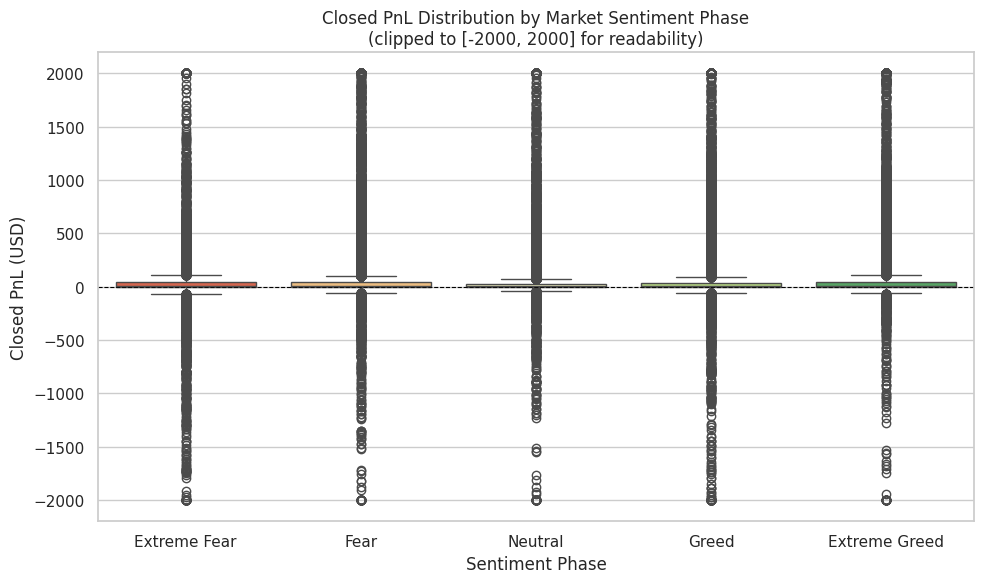

In [11]:
# Chart 1: PnL distribution by sentiment phase
plot_df = merged[merged['Closed PnL'] != 0].copy()
plot_df['clipped_pnl'] = plot_df['Closed PnL'].clip(-2000, 2000)  # clip extreme outliers for readability

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x='classification', y='clipped_pnl', order=sentiment_order, palette='RdYlGn')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Closed PnL Distribution by Market Sentiment Phase\n(clipped to [-2000, 2000] for readability)')
plt.xlabel('Sentiment Phase')
plt.ylabel('Closed PnL (USD)')
plt.tight_layout()
plt.savefig('pnl_by_sentiment.png', dpi=120)
plt.show()


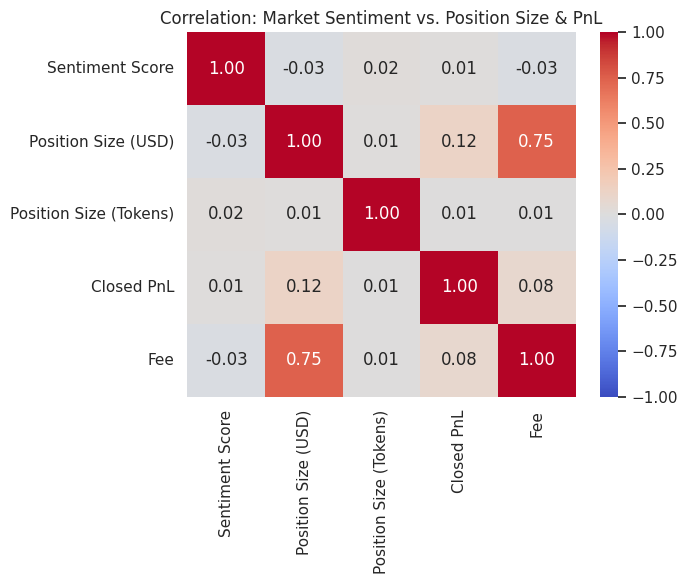

In [12]:
# Chart 2: Correlation heatmap - sentiment score, position size, PnL
corr_cols = merged[['value', 'Size USD', 'Size Tokens', 'Closed PnL', 'Fee']].copy()
corr_cols.columns = ['Sentiment Score', 'Position Size (USD)', 'Position Size (Tokens)', 'Closed PnL', 'Fee']

plt.figure(figsize=(7, 6))
sns.heatmap(corr_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation: Market Sentiment vs. Position Size & PnL')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()


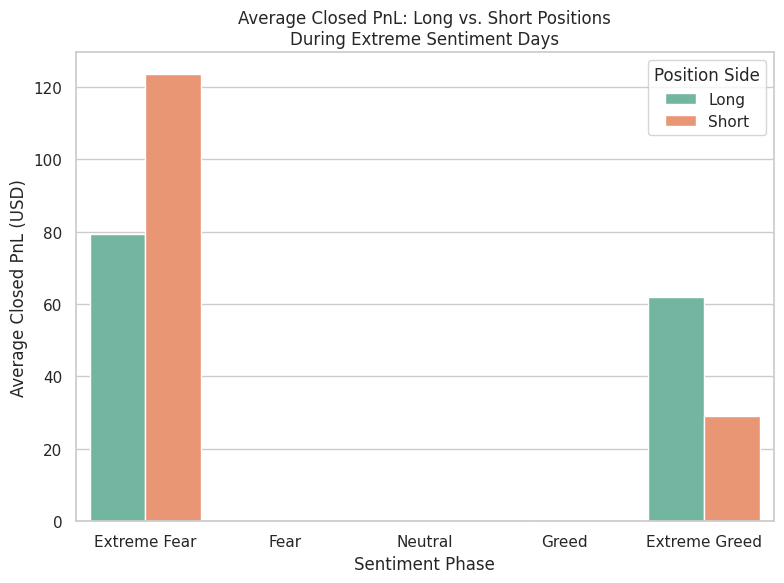

In [13]:
# Chart 3: Long vs Short performance during extreme sentiment days
extreme = merged[merged['classification'].isin(['Extreme Fear', 'Extreme Greed'])].copy()
extreme = extreme[extreme['Closed PnL'] != 0]

# Map Direction into a clean Long/Short label
def side_label(d):
    if 'Long' in str(d):
        return 'Long'
    elif 'Short' in str(d):
        return 'Short'
    return None

extreme['position_side'] = extreme['Direction'].apply(side_label)
extreme = extreme.dropna(subset=['position_side'])

side_perf = extreme.groupby(['classification', 'position_side'], observed=True)['Closed PnL'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=side_perf, x='classification', y='Closed PnL', hue='position_side', palette='Set2')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Average Closed PnL: Long vs. Short Positions\nDuring Extreme Sentiment Days')
plt.xlabel('Sentiment Phase')
plt.ylabel('Average Closed PnL (USD)')
plt.legend(title='Position Side')
plt.tight_layout()
plt.savefig('long_short_extreme_sentiment.png', dpi=120)
plt.show()


## Step 5: Statistical Validation

In [14]:
# Descriptive stats of trader profitability per sentiment tier
stats_table = closed.groupby('classification', observed=True)['Closed PnL'].describe()
stats_table


,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,10406.0,71.027316,1628.408341,-31036.69194,0.024314,6.388050,44.111504,115287.00000
Extreme Greed,20853.0,130.205309,1058.126139,-10259.46800,1.143404,8.530740,44.441362,44223.45187
Fear,29808.0,112.625988,1344.778427,-35681.74723,0.628873,6.350483,40.268687,135329.09010
Greed,25176.0,85.403927,1576.394764,-117990.10410,0.049465,4.927600,36.918150,74530.52371
Neutral,18159.0,71.199993,743.212863,-24500.00000,0.224754,4.583458,29.024415,48504.09555


In [15]:
# Win rate summary per sentiment tier (all accounts pooled)
overall_win_rate = closed.groupby('classification', observed=True)['is_win'].mean().sort_values(ascending=False)
print("Win rate by sentiment phase:")
print(overall_win_rate)


Win rate by sentiment phase:
classification
Extreme Greed    0.891670
Fear             0.872886
Neutral          0.823889
Greed            0.768907
Extreme Fear     0.762156
Name: is_win, dtype: float64


In [16]:
# Position size (leverage proxy) vs sentiment - mean & median by tier
size_by_sentiment = merged.groupby('classification', observed=True)['Size USD'].agg(['mean','median','std']).round(2)
size_by_sentiment


,mean,median,std
classification,,,
Extreme Fear,5349.73,766.15,22306.83
Fear,7817.50,736.14,51919.37
Neutral,4782.73,547.66,37461.88
Greed,5739.17,555.00,30539.28
Extreme Greed,3113.19,500.06,11063.53


In [17]:
# Long vs Short win rate specifically in extreme sentiment (supports Chart 3)
extreme['is_win'] = extreme['Closed PnL'] > 0
extreme_win_rate = extreme.groupby(['classification','position_side'], observed=True)['is_win'].mean().round(3)
extreme_win_rate


classification  position_side
Extreme Fear    Long             0.847
                Short            0.706
Extreme Greed   Long             0.888
                Short            0.860
Name: is_win, dtype: float64

## Summary of Findings
See the project `README.md` for the business-facing summary of these results.